In [17]:
from pysph.solver.utils import load
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# plt.style.use('dark_background')

path = Path('../fast-sph-packing').resolve()

import sys
if path not in sys.path:
    sys.path.append(str(path))

In [18]:
!python ../fast-sph-packing/cases/adapt_circle.py --openmp -d outputs/circ5 --adapt-freq=-1 --detailed-output --nperturb 0 --noise 0 --spacing 0.2

Traceback (most recent call last):
  File "/home/navaneet/pypro/spheric-packing/../fast-sph-packing/cases/adapt_circle.py", line 3, in <module>
    from packing.packer import Packer
ModuleNotFoundError: No module named 'packing'


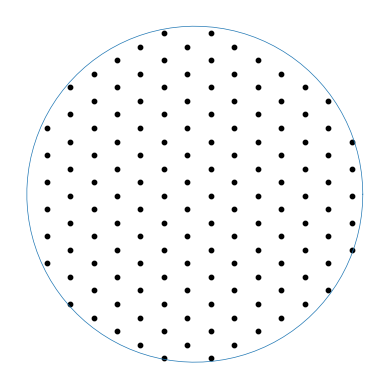

In [27]:
data = load('outputs/circ6/circ_00000.hdf5')
pa = data['arrays']['free']
x = pa.x
y = pa.y

r = np.sqrt(x**2 + y**2)
ins = r < 1.0

theta = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots()
ax.scatter(x[ins]-1e-2, y[ins], s=10, c='black', alpha=1.0)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

ax.set_aspect('equal')
ax.axis('off')

plt.savefig('assets/nocircle_nopack.png', dpi=300, bbox_inches='tight')
ax.plot(np.cos(theta), np.sin(theta), color='tab:blue', lw=0.5)

plt.savefig('assets/circle_nopack.png', dpi=300, bbox_inches='tight')


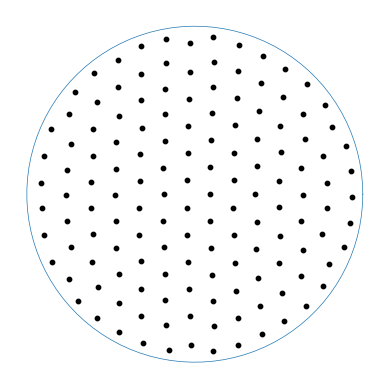

In [28]:
data = load('outputs/circ6/circ_00988.hdf5')
pa = data['arrays']['free']
x = pa.x
y = pa.y

r = np.sqrt(x**2 + y**2)
ins = r < 1.0

theta = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots()
ax.scatter(x[ins], y[ins], s=10, c='k', alpha=1.0)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.axis('off')

plt.savefig('assets/nocircle_pack.png', dpi=300, bbox_inches='tight')
ax.plot(np.cos(theta), np.sin(theta), color='tab:blue', lw=0.5)
plt.savefig('assets/circle_pack.png', dpi=300, bbox_inches='tight')

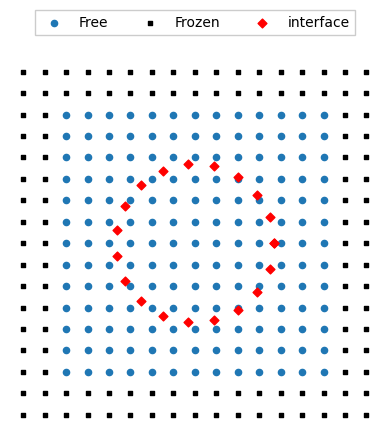

In [15]:
x, y = np.mgrid[-1.3:1.3:17j, -1.3:1.3:17j]
r = np.sqrt(x**2 + y**2)
frozenc = (x >1.0) | (y > 1.0) | (x < -1.0) | (y < -1.0)
freec = ~frozenc
thetas = np.linspace(0, 2*np.pi, 20)
xc, yc = 0.6 * np.cos(thetas), 0.6 * np.sin(thetas)

fig, ax = plt.subplots()
ax.scatter(x[freec], y[freec], s=20, marker='o', label='Free', c='tab:blue')
ax.scatter(x[frozenc], y[frozenc], s=12, marker='s', label='Frozen', c='k')
ax.scatter(xc, yc, s=20, c='r', marker='D', label='interface')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.legend(bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=3, fancybox=False, framealpha=1.0)
ax.axis('off')
figfile = 'assets/particle-sets.png'
plt.savefig(figfile, bbox_inches='tight', pad_inches=0.0, dpi=300)